In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from modules.LDS import Kalman_EM
from modules.WF_sim import *
from pathlib import Path

# WF simulation

A is not provide! A_demo is used.


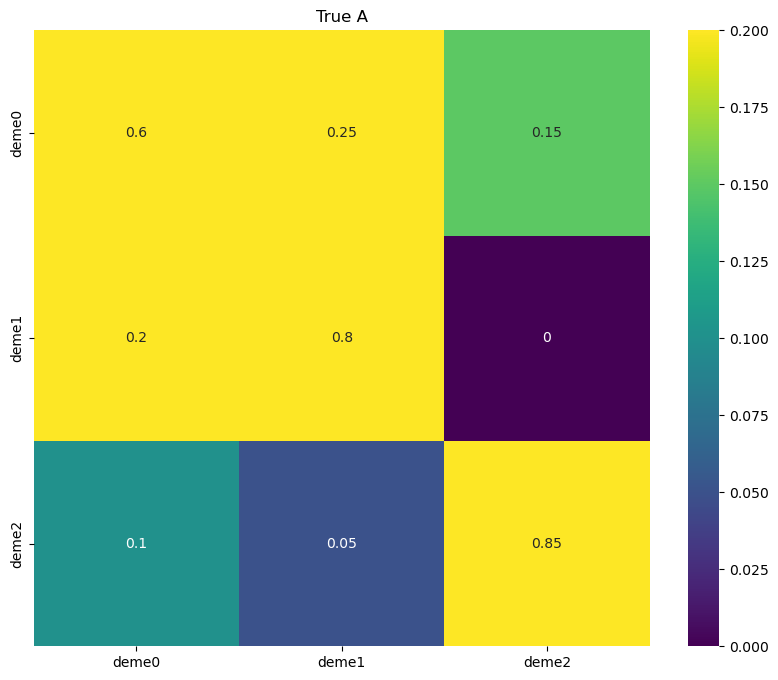

True Neff =  [2000, 2000, 2000]
True measurement noise overdispersion =  [1, 1, 1]


In [2]:
ND = 3 # the number of demes 
T=10 # the number of timepoints
Csn =[1]*ND # strength of measurement noise overdispersion
Npop = [2000]*ND # effective population size
totcounts = np.array([np.random.randint(1000, 3000, ND) for _ in range(T)]).T # number of sequences sampled from each region
A,counts,B=WF_sim(Npop,totcounts, Csn, ND, T, A=None,Ntraj=20)

demes=['deme'+str(i) for i in range(ND)]

plt.figure(figsize=[10,8])
sns.heatmap(A,cmap='viridis',vmax=0.2,annot=True,xticklabels=demes, yticklabels=demes,square=True)
plt.title('True A')
plt.show()

print("True Neff = ", Npop)
print("True measurement noise overdispersion = ", Csn )

## HMM-EM

T= Number of timepoints

NA= Number of alleles

ND = Number of demes

* INPUT
    * counts: spatio-temporal data of allele (or lineage) counts, with shape (ND, NA ,T).
    * totcounts: spatio-temporal data of total number of sampled sequences, with shape (ND, T).
* OUTPUT
    * lnLH_record: Record of log likelihood across EM cycles,
    * A_EM: Inferred A.
    * Ne_EM: Inferred effective population size.
    * A_LS: Least squares solution (noises ignored).
    * Csn_EM: Inferred measurment noise overdispersion.

terminate at step=40, DA=0.00047, ratioDNe=0.02436, ratioDCsn=0.00465


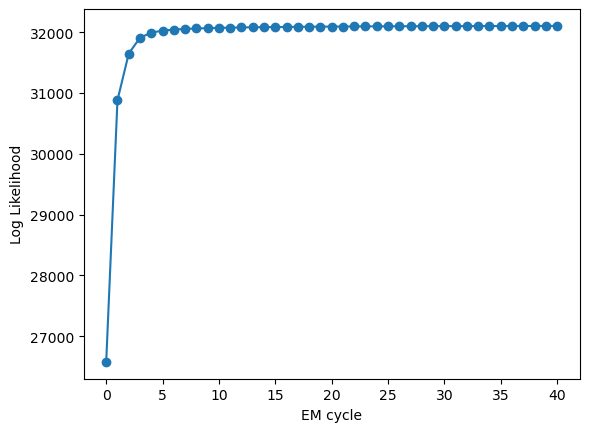

In [9]:
lnLH_record, A_EM, Ne_EM, A_LS,Csn_EM=Kalman_EM(counts=counts+1, 
                                             counts_deme=totcounts, 
                                             em_step_max=100,terminate_th=0.001, 
                                             frac=0.5,noisemode=2,Qprintstep=False)

plt.plot(lnLH_record,marker='o')
plt.xlabel('EM cycle')
plt.ylabel('Log Likelihood')
plt.show()

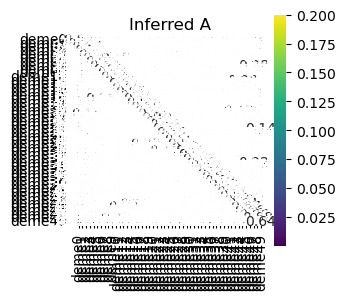

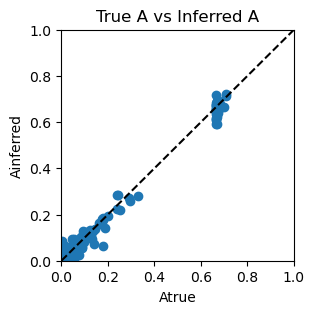

Inferred Neff =  [ 4164.00156492  4630.43988163  3548.33572658  2415.25947115
  5852.59918888  4589.94612731  5418.42491172  2505.75448235
  2169.62362942  3544.03892918  4718.26803469  2417.69696423
  2844.47320875  2814.7070357   4396.07205955  4274.27686887
  3057.18320131  5412.04889224  5257.89292948  6332.18976524
  3588.62530464  2596.02937758  4426.03405381  3128.55146506
  2213.687323    3819.06105846  2878.27257397  3229.55150415
  3046.82548259  2697.69375003  2672.08702482  3803.52967108
  5190.25017362  1995.88909368  2155.07152383  2792.01242101
  4893.82403823 10979.52247006  3886.92754985  2325.88340791
  9289.98295335  2220.42009424  2707.34435845  2796.68767919
  2569.35908278  1761.06905339  5302.57378429  4905.25838179
  3039.32472425  3726.54484983]
Inferred measurement noise overdispersion =  [1.218199  1.1496565 1.2013177 1.4409704 1.3253647 1.4368558 1.3412523
 1.4521226 1.1286298 1.        1.0726616 1.4219154 1.162228  1.0712699
 1.3471812 1.0871768 1.        1

In [11]:
plt.figure(figsize=[3,3])
sns.heatmap(A_EM,cmap='viridis',vmax=0.2,annot=True,xticklabels=demes, yticklabels=demes,square=True)
plt.title('Inferred A')
plt.show()

plt.figure(figsize=(3,3))
plt.scatter(A.flatten(),A_EM.flatten())
plt.plot([0,1],'--',color='k')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Atrue')
plt.ylabel('Ainferred')
plt.title('True A vs Inferred A')
plt.show()

print("Inferred Neff = ", Ne_EM)
print("Inferred measurement noise overdispersion = ", Csn_EM)

# HMM-EM and bootstrapping

In [14]:
# Perform bootstrapping 
def bootstrap_data(counts, size):
    ND, Ntraj, T = counts.shape
    return np.array([counts[:,np.random.choice(list(range(Ntraj)),size = Ntraj,replace = True),:] for _ in range(size)])

bootstrap_counts = bootstrap_data(counts, size=10) # only 10 bootstrapped datasets are generated for demonstration purposes.


## Compute in this notebook 

In [17]:

res_A_EM=[]
for BS_counts in bootstrap_counts:
    lnLH_record, A_EM, Ne_EM, A_LS,Csn_EM=Kalman_EM(counts=BS_counts+1, 
                                                counts_deme=totcounts, 
                                                em_step_max=100,terminate_th=0.001, 
                                                frac=0.5,noisemode=2,Qprintstep=False)
    
    res_A_EM.append(A_EM)
res_A_EM=np.array(res_A_EM)


A_EM_mean = np.mean(res_A_EM,axis=0)
A_EM_std  = np.std(res_A_EM,axis=0)

A_EM_mean, A_EM_std 


terminate at step=80, DA=0.00079, ratioDNe=0.02424, ratioDCsn=0.00317
terminate at step=82, DA=0.001, ratioDNe=0.01688, ratioDCsn=0.00235
terminate at step=62, DA=0.00098, ratioDNe=0.02289, ratioDCsn=0.00306
terminate at step=51, DA=0.00059, ratioDNe=0.02489, ratioDCsn=0.00349
terminate at step=43, DA=0.00083, ratioDNe=0.02493, ratioDCsn=0.00451
terminate at step=51, DA=0.00069, ratioDNe=0.02497, ratioDCsn=0.00348
terminate at step=48, DA=0.00091, ratioDNe=0.02458, ratioDCsn=0.00401
terminate at step=51, DA=0.00095, ratioDNe=0.02418, ratioDCsn=0.00471
terminate at step=65, DA=0.00097, ratioDNe=0.02116, ratioDCsn=0.00358
terminate at step=56, DA=0.001, ratioDNe=0.02394, ratioDCsn=0.00548


(array([[5.78860780e-01, 6.72997635e-06, 7.53338121e-03, ...,
         4.03048908e-06, 1.40163730e-02, 2.95941523e-06],
        [1.44265953e-03, 6.74772922e-01, 2.76270277e-05, ...,
         6.29958973e-06, 7.92163678e-04, 2.56290561e-04],
        [7.20149226e-06, 1.86466675e-02, 6.28980377e-01, ...,
         2.25476512e-02, 9.28938116e-02, 3.66545799e-03],
        ...,
        [4.47707304e-03, 1.07039346e-05, 9.52949209e-03, ...,
         6.65621601e-01, 2.93265500e-02, 1.81814329e-04],
        [1.61112065e-06, 2.00968649e-06, 6.42640278e-03, ...,
         1.72525994e-06, 6.72597231e-01, 3.27346192e-03],
        [3.40364390e-06, 3.39347022e-02, 6.55580039e-03, ...,
         2.01637396e-02, 3.11158388e-02, 6.11122866e-01]]),
 array([[4.68011984e-02, 9.27196526e-06, 1.49899496e-02, ...,
         4.80656524e-06, 1.21520624e-02, 2.60147550e-06],
        [4.23455546e-03, 2.04215309e-02, 6.01991449e-05, ...,
         8.40525093e-06, 2.33378478e-03, 5.98792335e-04],
        [1.62561643e-05, 

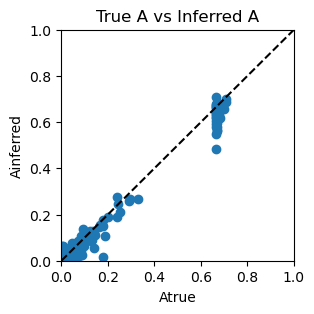

In [19]:
plt.figure(figsize=(3,3))
plt.scatter(A.flatten(),A_EM_mean.flatten())
plt.plot([0,1],'--',color='k')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Atrue')
plt.ylabel('Ainferred')
plt.title('True A vs Inferred A')
plt.show()

## Execute from command line

In [58]:
# Export input data
filename= 'WFsim'
np.save('HMM_EM/input/counts_'+filename+'.npy',bootstrap_counts)
np.save('HMM_EM/input/totcounts_'+filename+'.npy',totcounts)


In [59]:
import os
import subprocess

subprocess.run(["python","HMMEM.py", "WFsim"])  # May raise an error


filename: WFsim
noisemode: 2
ridge: 0.0
step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
terminate at step=16, DA=9e-05, ratioDNe=0.01237, ratioDCsn=0.00495
step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
terminate at step=18, DA=0.0001, ratioDNe=0.00785, ratioDCsn=0.00427
step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
step 19
step 20
step 21
step 22
step 23
step 24
step 25
step 26
step 27
step 28
step 29
step 30
step 31
step 32
step 33
step 34
step 35
step 36
terminate at step=36, DA=0.0001, ratioDNe=0.00813, ratioDCsn=0.00244
step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
step 19
step 20
step 21
step 22
terminate at step=22, DA=0

CompletedProcess(args=['python', 'HMMEM.py', 'WFsim'], returncode=0)

In [60]:
res_A_EM=np.load("HMM_EM/output/A_ridge0.0_"+filename+".npy")
res_Ne_EM=np.load("HMM_EM/output/Ne_ridge0.0_"+filename+".npy")
res_Csn_EM=np.load("HMM_EM/output/Csn_ridge0.0_"+filename+".npy")

A_EM_mean = np.mean(res_A_EM,axis=0)
A_EM_std  = np.std(res_A_EM,axis=0)

A_EM_mean, A_EM_std 

(array([[5.47471228e-01, 2.84975016e-01, 1.67553756e-01],
        [1.93801458e-01, 8.05456272e-01, 7.42270628e-04],
        [1.06722312e-01, 6.29104280e-02, 8.30367260e-01]]),
 array([[0.01951604, 0.01134944, 0.01412968],
        [0.01778059, 0.01758707, 0.00143003],
        [0.03392765, 0.02302089, 0.01700497]]))

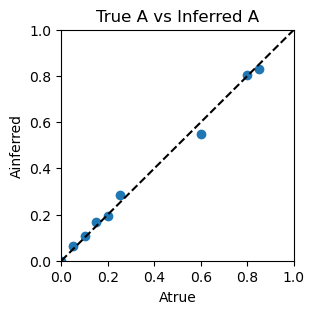

In [61]:
plt.figure(figsize=(3,3))
plt.scatter(A.flatten(),A_EM_mean.flatten())
plt.plot([0,1],'--',color='k')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Atrue')
plt.ylabel('Ainferred')
plt.title('True A vs Inferred A')
plt.show()

## HMM-MCMC (C++)

T= Number of timepoints

NA= Number of alleles

ND = Number of demes

* INPUT
    * counts: spatio-temporal data of allele (or lineage) counts. CSV file with shape (TxNA, ND). The frequencies of the i-th lineage at time t appears at the (i-1)*T + t -th row.
    * totcounts: spatio-temporal data of total number of sampled sequences. CSV file with shape (T, ND).
* OUTPUT
    * A_MCMC: Posterior distribution of A.
    * Ne_MCMC: Posterior distribution of effective population size.
    * Csn_MCMC: Posterior distribution of measurment noise overdispersion.
from modules.HMMtools import *

In [16]:
dir_IO ='demo'
filename='WFsim'

In [17]:
MCMC_dir = 'HMM_MCMC/'

inpath=MCMC_dir+'input/'#+dir_IO+'/'
Path(inpath).mkdir(parents=True, exist_ok=True)

ND,Nmut,tmax  = counts.shape

counts_  = counts.transpose()
shapelst=list(counts_.shape)

aux=np.vstack([counts_[:, i, :] for i in range(Nmut)])

np.savetxt(inpath+'counts_'+filename+'.csv', aux, fmt="%d", delimiter=",")
np.savetxt(inpath+'totcounts_'+filename+'.csv', totcounts.transpose(), fmt="%d", delimiter=",")
np.savetxt(inpath+'shape_'+filename+'.csv', shapelst, fmt="%d", delimiter=",") #  shapelist = #timepoints, #trajectories, #demes
    

In [18]:
import os
import subprocess
try:
    os.chdir("HMM_MCMC/")
    subprocess.run(["./NI_MCMC", "-f", "WFsim","-m", "100", "-n","2"])  # May raise an error
finally:
    os.chdir('..')



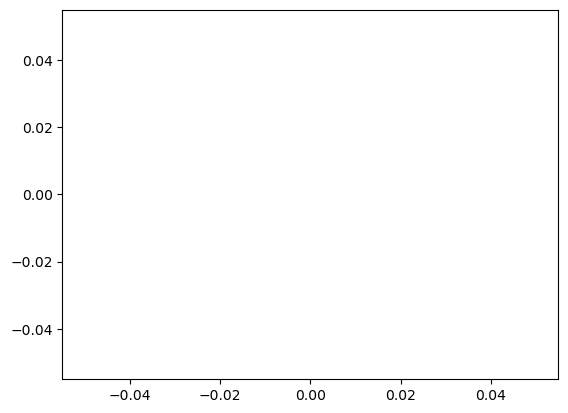

In [19]:
A_mcmc=np.loadtxt(MCMC_dir+'output/A_'+filename+'.csv',delimiter=',')
Ne_mcmc=np.loadtxt(MCMC_dir+'output/Ne_'+filename+'.csv',delimiter=',')
C_mcmc=np.loadtxt(MCMC_dir+'output/C_'+filename+'.csv',delimiter=',')
# Use genfromtxt to handle '-nan(ind)' as np.nan
logLH_mcmc = np.genfromtxt(MCMC_dir+'output/logLH_'+filename+'.csv', delimiter=',', dtype=float, missing_values='-nan(ind)', filling_values=np.nan)

A_mcmc=np.array([ i.reshape((Ne_mcmc.shape[1],Ne_mcmc.shape[1])) for i in A_mcmc])

plt.plot(logLH_mcmc[:,0],logLH_mcmc[:,1])
plt.show()

In [21]:
# Diagnostics: Check for NaNs and shapes after burn-in
print('A_mcmc shape:', A_mcmc.shape, 'NaNs:', np.isnan(A_mcmc).sum())
print('Ne_mcmc shape:', Ne_mcmc.shape, 'NaNs:', np.isnan(Ne_mcmc).sum())
print('C_mcmc shape:', C_mcmc.shape, 'NaNs:', np.isnan(C_mcmc).sum())
if 'logLH_mcmc' in locals():
    print('logLH_mcmc shape:', logLH_mcmc.shape, 'NaNs:', np.isnan(logLH_mcmc).sum())
    print('First 10 logLH_mcmc:', logLH_mcmc[:10])

A_mcmc shape: (100, 3, 3) NaNs: 0
Ne_mcmc shape: (100, 3) NaNs: 0
C_mcmc shape: (100, 3) NaNs: 0
logLH_mcmc shape: (100, 2) NaNs: 100
First 10 logLH_mcmc: [[ 0. nan]
 [ 1. nan]
 [ 2. nan]
 [ 3. nan]
 [ 4. nan]
 [ 5. nan]
 [ 6. nan]
 [ 7. nan]
 [ 8. nan]
 [ 9. nan]]


In [270]:
# Burn-in
burn_in=int(0.5*len(A_mcmc))
A_mcmc = A_mcmc[burn_in:]
Ne_mcmc= Ne_mcmc[burn_in:]
C_mcmc = C_mcmc[burn_in:]


In [15]:
# Print the A_mcmc array after burn-in
print('A_mcmc array after burn-in:')
print(A_mcmc)

A_mcmc array after burn-in:
[[[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  

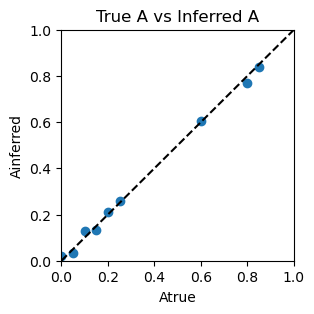

Inferred Neff =  [1827.321278 1485.65646  1727.911692]
Inferred measurement noise overdispersion =  [1.29273413 1.18138973 1.17137445]


In [271]:

plt.figure(figsize=(3,3))
plt.scatter(A.flatten(),np.mean(A_mcmc,axis=0).flatten())
plt.plot([0,1],'--',color='k')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Atrue')
plt.ylabel('Ainferred')
plt.title('True A vs Inferred A')
plt.show()

print("Inferred Neff = ", np.mean(Ne_mcmc,axis=0))
print("Inferred measurement noise overdispersion = ", np.mean(C_mcmc,axis=0))

## Non-negative Matrix Factorization (NMF) Analysis

Non-negative Matrix Factorization (NMF) is a dimensionality reduction technique that decomposes a non-negative matrix (such as the inferred transition matrix $A_{ij}$) into two lower-rank non-negative matrices. This allows us to identify latent features or modules within the transition matrix, providing insight into the underlying structure of migration or interaction rates between demes. Here, we apply NMF to the mean inferred $A_{ij}$ from bootstrapping to visualize and interpret its latent components.

* **INPUT**
    * `A_EM_mean`: Mean inferred transition matrix $A_{ij}$ from bootstrapping (shape: ND x ND).
    * `n_components`: Number of latent components to extract (user-defined).
* **OUTPUT**
    * `W`: NMF basis matrix (shape: ND x n_components).
    * `H`: NMF coefficient matrix (shape: n_components x ND).
    * Visualizations of the basis and coefficient matrices.

In [3]:
import numpy as np
# Load England Delta data for 9-deme and 50-deme cases (NPY format) with correct paths
npy_9_path = r'data/England_Delta_9_MCMC/output/A_England_Delta_9.npy'  # Update if your 9-deme file has a different name
npy_50_path = r'data/England_Delta_50_EM/output/A_England_Delta.npy'

try:
    data_9 = np.load(npy_9_path)
    print('9-deme data shape:', data_9.shape)
except Exception as e:
    print(f'Could not load 9-deme npy file: {e}')
    data_9 = None
data_50 = np.load(npy_50_path)
print('50-deme data shape:', data_50.shape)


# Flatten the 9-deme and 50-deme data arrays
if data_9 is not None:
    data_9_flat = data_9.reshape(data_9.shape[0], -1)
    print('9-deme flattened shape:', data_9_flat.shape)  # Should be (5000, 81)
else:
    data_9_flat = None
data_50_flat = data_50.reshape(data_50.shape[0], -1)
print('50-deme flattened shape:', data_50_flat.shape)  # Should be (100, 2500)

9-deme data shape: (5000, 9, 9)
50-deme data shape: (100, 50, 50)
9-deme flattened shape: (5000, 81)
50-deme flattened shape: (100, 2500)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment
import seaborn as sns


In [53]:
# We load the MCMC samples. Each sample is one plausible migration matrix
# drawn from the posterior distribution.
# Load the 9-deme MCMC samples
# Shape: (n_samples, n_demes, n_demes) = (5000, 9, 9)
data_9 = np.load(r'data/England_Delta_50_EM/output/A_England_Delta.npy')

n_samples, n_demes, _ = data_9.shape
print(f"Loaded {n_samples} MCMC samples")
print(f"Each sample is a {n_demes}x{n_demes} migration matrix")
print(f"Total shape: {data_9.shape}")
print()


Loaded 100 MCMC samples
Each sample is a 50x50 migration matrix
Total shape: (100, 50, 50)



In [54]:
def create_conditional_leaving_matrix(X):
    """
    Convert a row-stochastic migration matrix to a conditional-on-leaving matrix.

    Parameters:
    -----------
    X : array (n_demes, n_demes)
        Row-stochastic migration matrix where X[i,j] = prob of going from i to j

    Returns:
    --------
    Y : array (n_demes, n_demes)
        Conditional-on-leaving matrix (diagonal = 0, rows sum to 1 over off-diag)
    stay_probs : array (n_demes,)
        The original diagonal (stay probabilities)
    """
    X = X.copy().astype(float)
    n = X.shape[0]

    # Extract stay probabilities (diagonal)
    stay_probs = np.diag(X).copy()

    # Leave probabilities = 1 - stay
    leave_probs = 1.0 - stay_probs

    # Zero out the diagonal
    Y = X.copy()
    np.fill_diagonal(Y, 0.0)

    # Renormalize each row by probability of leaving
    # Y[i,:] = X[i,:] / leave_probs[i]  (for off-diagonal entries)
    for i in range(n):
        if leave_probs[i] > 1e-10:  # Avoid division by zero
            Y[i, :] /= leave_probs[i]
        else:
            # If leave_prob ≈ 0, set row to uniform (no info about where they'd go)
            Y[i, :] = 1.0 / (n - 1)
            Y[i, i] = 0.0

    return Y, stay_probs

# Apply to all MCMC samples
Y_all = []
stay_probs_all = []

for s in range(n_samples):
    Y, stay = create_conditional_leaving_matrix(data_9[s])
    Y_all.append(Y)
    stay_probs_all.append(stay)

Y_all = np.array(Y_all)           # (5000, 9, 9) - conditional-on-leaving matrices
stay_probs_all = np.array(stay_probs_all)  # (5000, 9) - stay probabilities

print(f"Created conditional-on-leaving matrices: {Y_all.shape}")
print(f"Stay probabilities extracted: {stay_probs_all.shape}")
print()

# Show statistics on the diagonal (stay probabilities)
mean_stay = stay_probs_all.mean(axis=0)
print("Mean stay probability by deme:")
for i in range(n_demes):
    print(f"  Deme {i+1}: {mean_stay[i]:.3f} (leave prob: {1-mean_stay[i]:.3f})")
print()

# Check: which demes have very low leave probability?
low_leave_threshold = 0.02
low_leave_demes = np.where((1 - mean_stay) < low_leave_threshold)[0]
if len(low_leave_demes) > 0:
    print(f"WARNING: Demes with leave prob < {low_leave_threshold}: {low_leave_demes + 1}")
    print("  These rows have little info about migration destinations.")
print()


Created conditional-on-leaving matrices: (100, 50, 50)
Stay probabilities extracted: (100, 50)

Mean stay probability by deme:
  Deme 1: 0.869 (leave prob: 0.131)
  Deme 2: 0.899 (leave prob: 0.101)
  Deme 3: 0.869 (leave prob: 0.131)
  Deme 4: 0.859 (leave prob: 0.141)
  Deme 5: 0.819 (leave prob: 0.181)
  Deme 6: 0.810 (leave prob: 0.190)
  Deme 7: 0.785 (leave prob: 0.215)
  Deme 8: 0.837 (leave prob: 0.163)
  Deme 9: 0.774 (leave prob: 0.226)
  Deme 10: 0.836 (leave prob: 0.164)
  Deme 11: 0.823 (leave prob: 0.177)
  Deme 12: 0.876 (leave prob: 0.124)
  Deme 13: 0.884 (leave prob: 0.116)
  Deme 14: 0.841 (leave prob: 0.159)
  Deme 15: 0.837 (leave prob: 0.163)
  Deme 16: 0.881 (leave prob: 0.119)
  Deme 17: 0.823 (leave prob: 0.177)
  Deme 18: 0.790 (leave prob: 0.210)
  Deme 19: 0.813 (leave prob: 0.187)
  Deme 20: 0.826 (leave prob: 0.174)
  Deme 21: 0.787 (leave prob: 0.213)
  Deme 22: 0.796 (leave prob: 0.204)
  Deme 23: 0.772 (leave prob: 0.228)
  Deme 24: 0.854 (leave prob: 0

In [56]:
X_all = Y_all.reshape(n_samples, -1)

print(f"Flattened shape: {X_all.shape}")
print(f"  - {X_all.shape[0]} rows (one per MCMC sample)")
print(f"  - {X_all.shape[1]} columns")
print()
print("NOTE: Diagonal entries are now 0, representing conditional-on-leaving.")
print()

Flattened shape: (100, 2500)
  - 100 rows (one per MCMC sample)
  - 2500 columns

NOTE: Diagonal entries are now 0, representing conditional-on-leaving.



In [57]:
def cosine_similarity(a, b):
    """
    Compute cosine similarity between two vectors.

    cos_sim(a, b) = (a · b) / (||a|| * ||b||)

    Returns a value between -1 and 1, where 1 means identical direction.
    """
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    if norm_a == 0 or norm_b == 0:
        return 0.0

    return dot_product / (norm_a * norm_b)


def build_similarity_matrix(H_ref, H_new):
    """
    Build a K x K cosine similarity matrix between two sets of components.

    Parameters:
    -----------
    H_ref : array (k, n_features)
        Reference components
    H_new : array (k, n_features)
        New components to compare

    Returns:
    --------
    similarity_matrix : array (k, k)
        similarity_matrix[i, j] = cosine similarity between H_ref[i] and H_new[j]
    """
    k = H_ref.shape[0]
    similarity_matrix = np.zeros((k, k))

    for i in range(k):
        for j in range(k):
            similarity_matrix[i, j] = cosine_similarity(H_ref[i], H_new[j])

    return similarity_matrix


def match_components(H_ref, H_new):
    """
    Match components in H_new to H_ref based on cosine similarity.

    Parameters:
    -----------
    H_ref : array (k, n_features)
        Reference components (from first bootstrap run)
    H_new : array (k, n_features)
        New components to be matched

    Returns:
    --------
    permutation : array of indices
        H_new[permutation] will be aligned with H_ref
    similarity_matrix : array (k, k)
        The cosine similarity matrix used for matching
    """
    # Build the K x K similarity matrix
    similarity_matrix = build_similarity_matrix(H_ref, H_new)

    # Convert to cost matrix (negative because Hungarian minimizes)
    # We want to maximize similarity, so we negate it
    cost_matrix = -similarity_matrix

    # Hungarian algorithm finds the optimal assignment
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    return col_ind, similarity_matrix  # Return both permutation and similarity matrix

print("Helper functions defined:")
print("  - cosine_similarity(a, b)")
print("  - build_similarity_matrix(H_ref, H_new)")
print("  - match_components(H_ref, H_new)")
print()


Helper functions defined:
  - cosine_similarity(a, b)
  - build_similarity_matrix(H_ref, H_new)
  - match_components(H_ref, H_new)



In [60]:
n_components = 3      # Number of NMF components to extract
n_bootstrap = 50      # Number of bootstrap iterations (increase for more robust results)
random_seed = 42
n_subsample = 60     # Number of MCMC samples to resample per bootstrap
# NMF parameters for proportional data
# - KL divergence: better for comparing distributions (rows are proportions)
# - Sparsity (alpha_H with l1_ratio=1): encourages distinct, interpretable motifs
use_kl_divergence = True
alpha_H = 0.05        # Sparsity regularization on H (try 0.01, 0.05, 0.1)
l1_ratio = 1.0        # 1.0 = pure L1 (sparse), 0.0 = pure L2 (smooth)

np.random.seed(random_seed)

# Storage for all bootstrap results
all_H = []            # Will store H matrices from each bootstrap
all_W = []            # Will store W matrices from each bootstrap

print(f"Running {n_bootstrap} bootstrap iterations with {n_components} NMF components...")
print(f"  Using KL divergence: {use_kl_divergence}")
print(f"  Sparsity alpha_H: {alpha_H}, l1_ratio: {l1_ratio}")
print("-" * 40)

for b in range(n_bootstrap):
    # ----- Step 4a: Resample with replacement -----
    # Draw n_samples indices from [0, n_samples) with replacement
    resample_idx = np.random.choice(n_samples, size=n_subsample, replace=True)

    # Get the resampled data
    X_boot = X_all[resample_idx]

    # ----- Step 4b: Run NMF -----
    # Using KL divergence (better for proportions) and sparsity regularization
    if use_kl_divergence:
        nmf = NMF(
            n_components=n_components,
            init='nndsvda',
            solver='mu',              # Multiplicative update (required for KL)
            beta_loss='kullback-leibler',
            max_iter=1000,
            random_state=b,
            alpha_H=alpha_H,
            l1_ratio=l1_ratio
        )
    else:
        nmf = NMF(
            n_components=n_components,
            init='nndsvda',
            max_iter=500,
            random_state=b
        )

    W = nmf.fit_transform(X_boot)  # (n_samples, n_components) - weights
    H = nmf.components_             # (n_components, 81) - the patterns

    all_H.append(H)
    all_W.append(W)

    if (b + 1) % 10 == 0:
        print(f"  Completed {b + 1}/{n_bootstrap} iterations")

print("-" * 40)
print(f"Done! Collected {len(all_H)} sets of components.")
print()

Running 50 bootstrap iterations with 3 NMF components...
  Using KL divergence: True
  Sparsity alpha_H: 0.05, l1_ratio: 1.0
----------------------------------------
  Completed 10/50 iterations
  Completed 20/50 iterations
  Completed 30/50 iterations
  Completed 40/50 iterations
  Completed 50/50 iterations
----------------------------------------
Done! Collected 50 sets of components.



Matched components shape: (50, 3, 2500)
  - 50 bootstrap runs
  - 3 components per run
  - 2500 features per component

Example: Similarity matrix from bootstrap run 1 (before matching):
  Shape: (3, 3) (K x K where K = 3)

  Similarity matrix:
  [ 0.923 0.882 0.862 ]
  [ 0.813 0.867 0.884 ]
  [ 0.937 0.772 0.872 ]



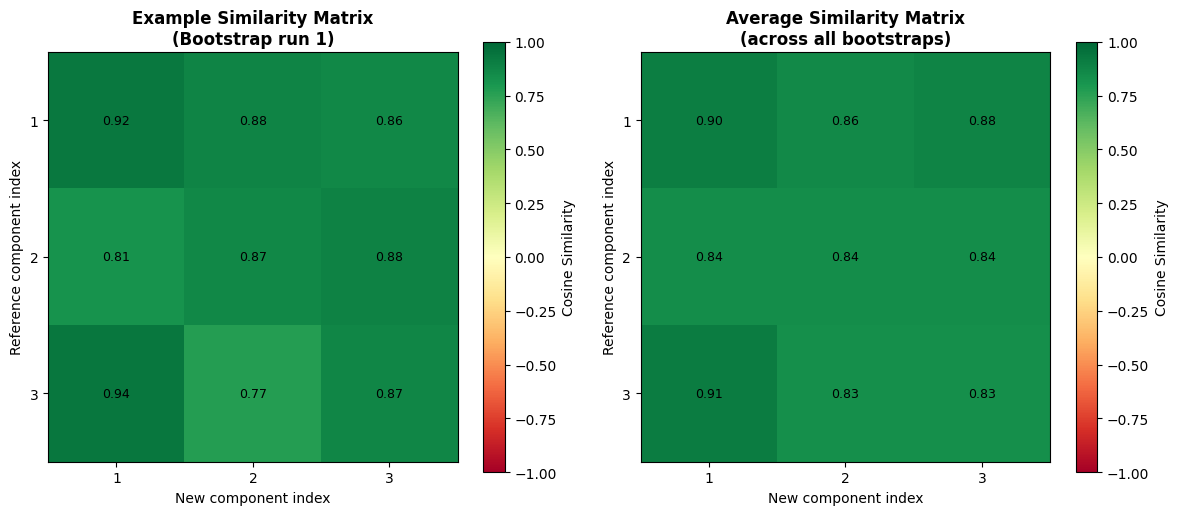

In [61]:
H_ref = all_H[0]

# Match all other runs to the reference
matched_H = [H_ref]  # First one is already the reference
all_similarity_matrices = []  # Store similarity matrices for analysis

for b in range(1, n_bootstrap):
    H_new = all_H[b]

    # Find the best permutation using cosine similarity
    perm, sim_matrix = match_components(H_ref, H_new)

    # Store the similarity matrix
    all_similarity_matrices.append(sim_matrix)

    # Apply the permutation to align with reference
    H_matched = H_new[perm]
    matched_H.append(H_matched)

# Convert to array: (n_bootstrap, n_components, n_features)
matched_H = np.array(matched_H)

print(f"Matched components shape: {matched_H.shape}")
print(f"  - {matched_H.shape[0]} bootstrap runs")
print(f"  - {matched_H.shape[1]} components per run")
print(f"  - {matched_H.shape[2]} features per component")
print()

# Show an example similarity matrix
print("Example: Similarity matrix from bootstrap run 1 (before matching):")
example_sim_matrix = all_similarity_matrices[0]
print(f"  Shape: {example_sim_matrix.shape} (K x K where K = {n_components})")
print()
print("  Similarity matrix:")
for i in range(n_components):
    row_str = "  ["
    for j in range(n_components):
        row_str += f" {example_sim_matrix[i, j]:.3f}"
    row_str += " ]"
    print(row_str)
print()

# Visualize the average similarity matrix across all bootstraps
avg_sim_matrix = np.mean(all_similarity_matrices, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot example similarity matrix
im1 = axes[0].imshow(example_sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('Example Similarity Matrix\n(Bootstrap run 1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('New component index')
axes[0].set_ylabel('Reference component index')
axes[0].set_xticks(range(n_components))
axes[0].set_yticks(range(n_components))
axes[0].set_xticklabels(range(1, n_components + 1))
axes[0].set_yticklabels(range(1, n_components + 1))
plt.colorbar(im1, ax=axes[0], label='Cosine Similarity')

# Add text annotations
for i in range(n_components):
    for j in range(n_components):
        axes[0].text(j, i, f'{example_sim_matrix[i, j]:.2f}',
                     ha='center', va='center', fontsize=9)

# Plot average similarity matrix
im2 = axes[1].imshow(avg_sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_title('Average Similarity Matrix\n(across all bootstraps)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('New component index')
axes[1].set_ylabel('Reference component index')
axes[1].set_xticks(range(n_components))
axes[1].set_yticks(range(n_components))
axes[1].set_xticklabels(range(1, n_components + 1))
axes[1].set_yticklabels(range(1, n_components + 1))
plt.colorbar(im2, ax=axes[1], label='Cosine Similarity')

# Add text annotations
for i in range(n_components):
    for j in range(n_components):
        axes[1].text(j, i, f'{avg_sim_matrix[i, j]:.2f}',
                     ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [62]:
component_means = matched_H.mean(axis=0)  # (n_components, n_features)
component_stds = matched_H.std(axis=0)    # (n_components, n_features)

# Compute stability score for each component
# = average cosine similarity between each bootstrap's component and the mean component
stability_scores = []
all_similarities = []  # Store all cosine similarities for visualization

for k in range(n_components):
    similarities = []
    for b in range(n_bootstrap):
        # Cosine similarity between this bootstrap's component k and the mean component k
        cos_sim = cosine_similarity(matched_H[b, k], component_means[k])
        similarities.append(cos_sim)

    all_similarities.append(similarities)
    stability_scores.append(np.mean(similarities))

# Print results
print()
print("Interpretation:")
print("  - Score near 1.0 = Stable component (real structure)")
print("  - Score near 0.0 = Unstable component (noise)")
print()

for k in range(n_components):
    score = stability_scores[k]
    status = "STABLE" if score > 0.8 else ("MODERATE" if score > 0.5 else "UNSTABLE")
    print(f"Component {k+1}: stability = {score:.3f}  [{status}]")
print()


Interpretation:
  - Score near 1.0 = Stable component (real structure)
  - Score near 0.0 = Unstable component (noise)

Component 1: stability = 0.939  [STABLE]
Component 2: stability = 0.935  [STABLE]
Component 3: stability = 0.957  [STABLE]



C:\Users\garva\AppData\Local\Temp\ipykernel_18760\2479285004.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(all_similarities, labels=range(1, n_components + 1))


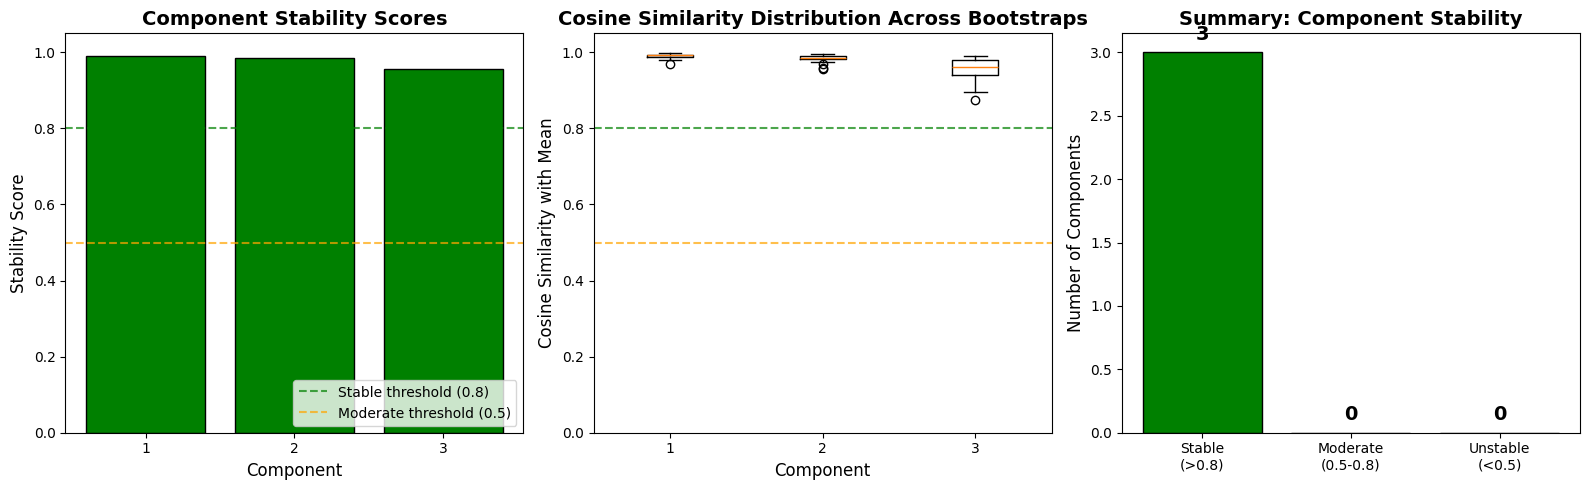

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ----- Plot 1: Stability scores bar plot -----
colors = ['green' if s > 0.8 else ('orange' if s > 0.5 else 'red') for s in stability_scores]
axes[0].bar(range(1, n_components + 1), stability_scores, color=colors, edgecolor='black')
axes[0].axhline(0.8, color='green', linestyle='--', alpha=0.7, label='Stable threshold (0.8)')
axes[0].axhline(0.5, color='orange', linestyle='--', alpha=0.7, label='Moderate threshold (0.5)')
axes[0].set_xlabel('Component', fontsize=12)
axes[0].set_ylabel('Stability Score', fontsize=12)
axes[0].set_title('Component Stability Scores', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[0].set_xticks(range(1, n_components + 1))

# ----- Plot 2: Correlation boxplot -----
axes[1].boxplot(all_similarities, labels=range(1, n_components + 1))
axes[1].axhline(0.8, color='green', linestyle='--', alpha=0.7)
axes[1].axhline(0.5, color='orange', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Component', fontsize=12)
axes[1].set_ylabel('Cosine Similarity with Mean', fontsize=12)
axes[1].set_title('Cosine Similarity Distribution Across Bootstraps', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.05)

# ----- Plot 3: Summary -----
# Show number of stable vs unstable components
n_stable = sum(1 for s in stability_scores if s > 0.8)
n_moderate = sum(1 for s in stability_scores if 0.5 < s <= 0.8)
n_unstable = sum(1 for s in stability_scores if s <= 0.5)

axes[2].bar(['Stable\n(>0.8)', 'Moderate\n(0.5-0.8)', 'Unstable\n(<0.5)'],
            [n_stable, n_moderate, n_unstable],
            color=['green', 'orange', 'red'], edgecolor='black')
axes[2].set_ylabel('Number of Components', fontsize=12)
axes[2].set_title('Summary: Component Stability', fontsize=14, fontweight='bold')

for i, v in enumerate([n_stable, n_moderate, n_unstable]):
    axes[2].text(i, v + 0.1, str(v), ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


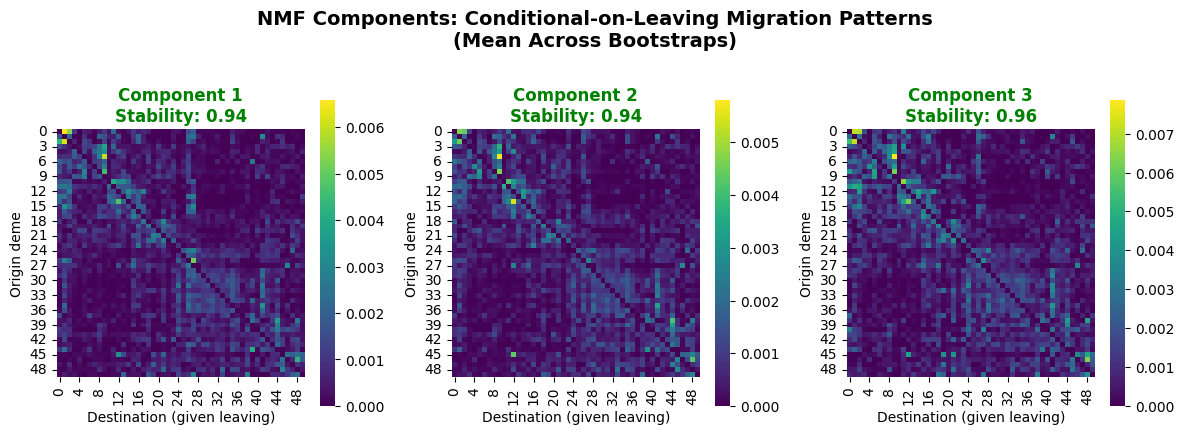

In [63]:
fig, axes = plt.subplots(1, n_components, figsize=(4 * n_components, 4))

for k in range(n_components):
    # Reshape the mean component back to a 9x9 matrix
    pattern = component_means[k].reshape(n_demes, n_demes)

    # Determine color based on stability
    stability = stability_scores[k]
    title_color = 'green' if stability > 0.8 else ('orange' if stability > 0.5 else 'red')

    # Plot heatmap
    sns.heatmap(pattern, ax=axes[k], cmap='viridis', square=True,
                cbar=True, annot=False)
    axes[k].set_title(f'Component {k+1}\nStability: {stability:.2f}',
                      fontsize=12, color=title_color, fontweight='bold')
    axes[k].set_xlabel('Destination (given leaving)')
    axes[k].set_ylabel('Origin deme')

plt.suptitle('NMF Components: Conditional-on-Leaving Migration Patterns\n(Mean Across Bootstraps)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


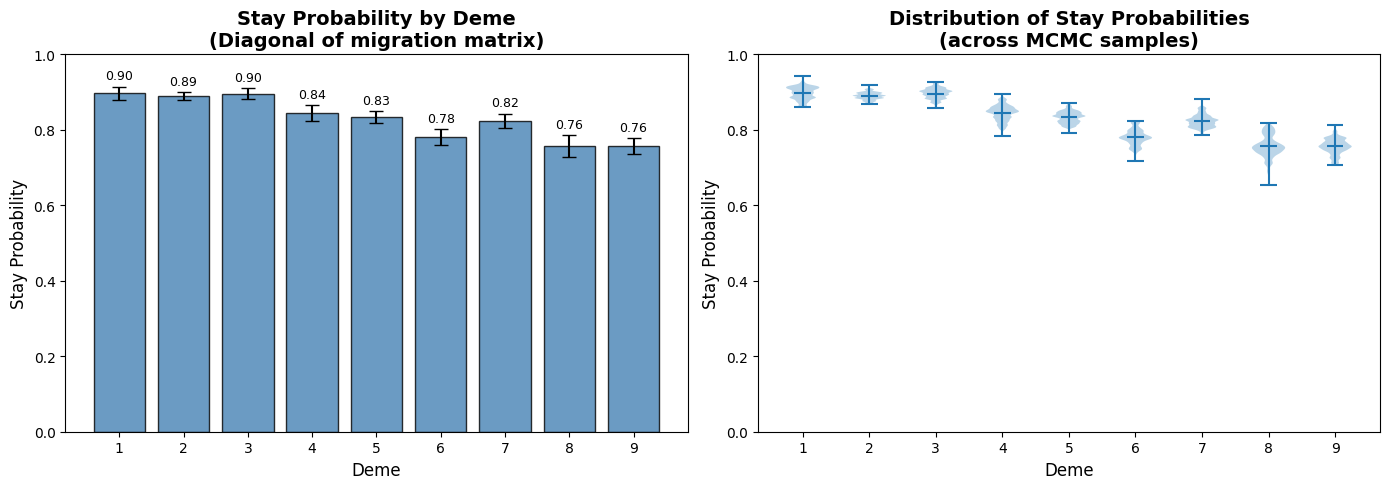

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean stay probability by deme
mean_stay = stay_probs_all.mean(axis=0)
std_stay = stay_probs_all.std(axis=0)

axes[0].bar(range(1, n_demes + 1), mean_stay, yerr=std_stay, capsize=5,
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Deme', fontsize=12)
axes[0].set_ylabel('Stay Probability', fontsize=12)
axes[0].set_title('Stay Probability by Deme\n(Diagonal of migration matrix)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(range(1, n_demes + 1))

# Add value labels
for i, (m, s) in enumerate(zip(mean_stay, std_stay)):
    axes[0].text(i + 1, m + s + 0.02, f'{m:.2f}', ha='center', fontsize=9)

# Plot 2: Distribution of stay probabilities across all samples
axes[1].violinplot(stay_probs_all, positions=range(1, n_demes + 1), showmeans=True)
axes[1].set_xlabel('Deme', fontsize=12)
axes[1].set_ylabel('Stay Probability', fontsize=12)
axes[1].set_title('Distribution of Stay Probabilities\n(across MCMC samples)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_xticks(range(1, n_demes + 1))

plt.tight_layout()
plt.show()


In [30]:
print(f"\nBootstrap iterations: {n_bootstrap}")
print(f"NMF components: {n_components}")
print(f"MCMC samples used: {n_samples}")
print(f"KL divergence: {use_kl_divergence}")
print(f"Sparsity: alpha_H={alpha_H}, l1_ratio={l1_ratio}")
print()
print("KEY PREPROCESSING: Conditional-on-leaving transformation")
print("  - Diagonal (stay probabilities) removed and analyzed separately")
print("  - Each row now represents 'given you leave, where do you go?'")
print()
print("Component stability:")
for k in range(n_components):
    score = stability_scores[k]
    status = "STABLE (real structure)" if score > 0.8 else ("MODERATE" if score > 0.5 else "UNSTABLE (noise)")
    print(f"  Component {k+1}: {score:.3f} - {status}")
print()
print(f"Stable components: {n_stable}/{n_components}")
print(f"Unstable components: {n_unstable}/{n_components}")
print()
if n_stable > n_unstable:
    print("CONCLUSION: Evidence of real latent structure in migration patterns.")
elif n_stable == 0:
    print("CONCLUSION: No stable components found. NMF may be fitting noise.")
else:
    print("CONCLUSION: Mixed results. Some structure, but interpret carefully.")
print("=" * 60)


Bootstrap iterations: 10
NMF components: 5
MCMC samples used: 5000
KL divergence: True
Sparsity: alpha_H=0.3, l1_ratio=1.0

KEY PREPROCESSING: Conditional-on-leaving transformation
  - Diagonal (stay probabilities) removed and analyzed separately
  - Each row now represents 'given you leave, where do you go?'

Component stability:
  Component 1: 1.000 - STABLE (real structure)
  Component 2: 1.000 - STABLE (real structure)
  Component 3: 0.997 - STABLE (real structure)
  Component 4: 0.999 - STABLE (real structure)
  Component 5: 1.000 - STABLE (real structure)

Stable components: 5/5
Unstable components: 0/5

CONCLUSION: Evidence of real latent structure in migration patterns.


### This is the ablation code:

In [ ]:
# Load MCMC samples
data_9 = np.load(r'data/England_Delta_9_MCMC/output/A_England_Delta_9.npy')
n_samples, n_demes, _ = data_9.shape

print(f"Loaded {n_samples} MCMC samples, each {n_demes}x{n_demes}")

# Compute MLE as posterior mean
A_mle = data_9.mean(axis=0)
print(f"\nMLE (posterior mean) computed: {A_mle.shape}")

# Verify it's approximately row-stochastic
row_sums = A_mle.sum(axis=1)
print(f"Row sums (should be ~1): {row_sums}")
print()

# Show diagonal (stay probabilities) from MLE
print("MLE diagonal (stay probabilities):")
for i in range(n_demes):
    print(f"  Deme {i+1}: {A_mle[i,i]:.3f}")


X_all = data_9.reshape(n_samples, -1)


Loaded 5000 MCMC samples, each 9x9

MLE (posterior mean) computed: (9, 9)
Row sums (should be ~1): [0.99999999 0.99999997 0.99999998 1.00000006 1.00000007 0.99999999
 1.00000008 0.99999998 1.        ]

MLE diagonal (stay probabilities):
  Deme 1: 0.897
  Deme 2: 0.890
  Deme 3: 0.896
  Deme 4: 0.844
  Deme 5: 0.833
  Deme 6: 0.780
  Deme 7: 0.824
  Deme 8: 0.756
  Deme 9: 0.756


In [ ]:
n_components = 5
print(f"Extracting {n_components} NMF components...")

nmf = NMF(
    n_components=n_components,
    init='nndsvda',
    solver='mu',
    beta_loss='kullback-leibler',
    max_iter=2000,
    random_state=42,
    alpha_H=0.05,
    l1_ratio=1.0
)

W = nmf.fit_transform(X_all)  # (n_samples, K)
H = nmf.components_            # (K, 81)

print(f"NMF complete!")
print(f"  W shape: {W.shape} (sample weights)")
print(f"  H shape: {H.shape} (component patterns)")

In [ ]:
def get_eigenvalues(A):
    """Get eigenvalues of matrix A, sorted by magnitude."""
    eigenvalues = np.linalg.eigvals(A)
    # Sort by magnitude (descending)
    idx = np.argsort(np.abs(eigenvalues))[::-1]
    return eigenvalues[idx]

eig_mle = get_eigenvalues(A_mle)
print("Eigenvalues of MLE (sorted by magnitude):")
for i, e in enumerate(eig_mle):
    if np.iscomplex(e):
        print(f"  λ{i+1} = {e.real:.4f} + {e.imag:.4f}i  (|λ| = {np.abs(e):.4f})")
    else:
        print(f"  λ{i+1} = {e.real:.4f}  (|λ| = {np.abs(e):.4f})")

lambda2_baseline = np.abs(eig_mle[1])
print(f"\nBaseline |λ₂| = {lambda2_baseline:.4f}")

In [ ]:
def project_onto_basis(target, H_basis):
    """
    Project target vector onto NMF basis using non-negative least squares.

    target: flattened matrix to project (81,)
    H_basis: NMF components to project onto (K, 81)

    Returns: reconstructed vector (81,)
    """
    # NNLS solves: min ||target - H.T @ w||^2 subject to w >= 0
    # We need to solve: min ||target - w @ H||^2
    # This is equivalent to: min ||target.T - H.T @ w||^2
    w, residual = nnls(H_basis.T, target)
    reconstruction = w @ H_basis
    return reconstruction, w

# Flatten MLE for projection
A_mle_flat = A_mle.flatten()

# Store results
ablation_results = []

print("Removing each component and measuring eigenvalue change...\n")

for k in range(n_components):
    # Create reduced basis (all components except k)
    H_reduced = np.delete(H, k, axis=0)  # Remove row k

    # Project MLE onto reduced basis
    A_reconstructed_flat, weights = project_onto_basis(A_mle_flat, H_reduced)

    # Reshape back to matrix
    A_reconstructed = A_reconstructed_flat.reshape(n_demes, n_demes)

    # Ensure non-negative (numerical safety)
    A_reconstructed = np.maximum(A_reconstructed, 0)

    # Renormalize to row-stochastic (rows sum to 1)
    row_sums = A_reconstructed.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    A_reconstructed = A_reconstructed / row_sums

    # Compute eigenvalues
    eig_ablated = get_eigenvalues(A_reconstructed)
    lambda2_ablated = np.abs(eig_ablated[1])

    # Change from baseline
    delta_lambda2 = lambda2_ablated - lambda2_baseline
    pct_change = 100 * delta_lambda2 / lambda2_baseline

    ablation_results.append({
        'component': k + 1,
        'lambda2_baseline': lambda2_baseline,
        'lambda2_ablated': lambda2_ablated,
        'delta': delta_lambda2,
        'pct_change': pct_change,
        'A_reconstructed': A_reconstructed,
        'weights': weights
    })

    print(f"Component {k+1} removed:")
    print(f"  |λ₂| = {lambda2_ablated:.4f}  (baseline: {lambda2_baseline:.4f})")
    print(f"  Δ|λ₂| = {delta_lambda2:+.4f}  ({pct_change:+.1f}%)")
    if delta_lambda2 > 0:
        print(f"  → Removing this component INCREASES |λ₂| (SLOWER mixing)")
    else:
        print(f"  → Removing this component DECREASES |λ₂| (FASTER mixing)")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# ----- Plot 1: Eigenvalue comparison bar chart -----
ax = axes[0, 0]
components = [r['component'] for r in ablation_results]
lambda2_values = [r['lambda2_ablated'] for r in ablation_results]
colors = ['red' if r['delta'] > 0 else 'green' for r in ablation_results]

bars = ax.bar(components, lambda2_values, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(lambda2_baseline, color='blue', linestyle='--', linewidth=2, label=f'Baseline |λ₂| = {lambda2_baseline:.4f}')
ax.set_xlabel('Component Removed', fontsize=12)
ax.set_ylabel('|λ₂| After Ablation', fontsize=12)
ax.set_title('Second Eigenvalue After Removing Each Component', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(components)

# Add value labels
for bar, val in zip(bars, lambda2_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9)

# ----- Plot 2: Percent change bar chart -----
ax = axes[0, 1]
pct_changes = [r['pct_change'] for r in ablation_results]
colors = ['red' if p > 0 else 'green' for p in pct_changes]

bars = ax.bar(components, pct_changes, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Component Removed', fontsize=12)
ax.set_ylabel('% Change in |λ₂|', fontsize=12)
ax.set_title('Percent Change in Second Eigenvalue', fontsize=14, fontweight='bold')
ax.set_xticks(components)

# Add value labels
for bar, val in zip(bars, pct_changes):
    ypos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 1.5
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.1f}%', ha='center', fontsize=9)

# ----- Plot 3: Original MLE heatmap -----
ax = axes[0, 2]
sns.heatmap(A_mle, ax=ax, cmap='viridis', annot=True, fmt='.2f',
            square=True, cbar_kws={'label': 'Probability'})
ax.set_title('Original MLE (Posterior Mean)', fontsize=14, fontweight='bold')
ax.set_xlabel('To deme')
ax.set_ylabel('From deme')

# ----- Plots 4-6: Component patterns (top 3 by impact) -----
# Sort by absolute impact
sorted_results = sorted(ablation_results, key=lambda r: abs(r['delta']), reverse=True)

for idx, result in enumerate(sorted_results[:3]):
    ax = axes[1, idx]
    k = result['component'] - 1  # 0-indexed
    pattern = H[k].reshape(n_demes, n_demes)

    delta = result['delta']
    color = 'red' if delta > 0 else 'green'
    impact = "slows mixing" if delta > 0 else "speeds mixing"

    sns.heatmap(pattern, ax=ax, cmap='viridis', square=True, cbar=True)
    ax.set_title(f'Component {result["component"]} ({impact})\nΔ|λ₂| = {delta:+.4f}',
                 fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Destination (given leaving)')
    ax.set_ylabel('Origin deme')

plt.tight_layout()
plt.show()



In [ ]:
print(f"\nBaseline |λ₂| = {lambda2_baseline:.4f}")
print()

# Sort by impact
print("Components ranked by impact on mixing (most impactful first):")
print("-" * 60)
for r in sorted_results:
    k = r['component']
    delta = r['delta']
    pct = r['pct_change']

    if delta > 0.001:
        impact = "SLOWS mixing (removing it speeds things up)"
    elif delta < -0.001:
        impact = "SPEEDS mixing (removing it slows things down)"
    else:
        impact = "MINIMAL EFFECT on mixing"

    print(f"Component {k}: Δ|λ₂| = {delta:+.4f} ({pct:+.1f}%)")
    print(f"  → {impact}")
    print()

print("=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)
print("""
|λ₂| close to 1 → Slow mixing (populations stay segregated longer)
|λ₂| close to 0 → Fast mixing (rapid homogenization)

If removing component k INCREASES |λ₂|:
  → That component was helping mixing (connecting demes)
  → It represents migration pathways that homogenize populations

If removing component k DECREASES |λ₂|:
  → That component was hindering mixing
  → It represents migration patterns that keep populations distinct
""")
